<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/notebooks/stage_03_target_definition/stage_03a_target_investigation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **stage_03a_target_investigation**


Vamos a reformular el Stage 03 partiendo exclusivamente del análisis empírico del mercado, y que el target sea una consecuencia de los datos, no un supuesto previo. El objetivo es que el MNQ nos “revele” cuál es una meta económicamente lógica, frecuente y operable.

## **Configuración del Entorno**


### 0.1. Acceso a Drive

In [102]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 0.2. Importación de librerías


In [103]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

### 0.3. Definición de rutas

In [104]:
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

In [105]:
# ---------------------------------------------------------------------
# Configuración de rutas (DVC-friendly)
# ---------------------------------------------------------------------
# Estas rutas son RELATIVAS al repositorio.
# DVC necesita paths locales y determinísticos.
# Si mañana quiere apuntar a Drive, se hace vía DVC remote o symlink,
# NO cambiando la lógica del stage.

# PARA EL DVC:
IN_PARQUET = Path(os.environ.get("IN_PARQUET", "data/processed/mnq_intraday.parquet"))
OUT_PARQUET = Path(os.environ.get("OUT_PARQUET", "data/processed/mnq_intraday_labeled.parquet"))
OUT_SUMMARY = Path(os.environ.get("OUT_SUMMARY", "reports/target_definitio_summary.json"))

In [106]:
# PARA EL NOTEBOOK:
IN_PARQUET = DRIVE_DIR / IN_PARQUET
OUT_PARQUET = DRIVE_DIR / OUT_PARQUET
OUT_SUMMARY = DRIVE_DIR / OUT_SUMMARY

### 0.4. Carga de dataset `intraday_mnq`


In [107]:
def load_mnq_parquet():
    os.path.exists(IN_PARQUET)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(IN_PARQUET)
    return mnq_parquet

In [108]:
def add_column_date(df):
    # Asegurar que el índice esté en formato datetime
    df.index = pd.to_datetime(df.index)

    # Crear una nueva columna 'date' con la fecha extraída del índice
    df['date'] = df.index.date

    # Reordenar columnas: 'date', 'time_str', y luego el resto
    cols = ['date'] + [col for col in df.columns if col not in ['date']]

    df = df[cols]

    return df

In [109]:
def info_dataset(df):
  print("Información del dataset:\n")

  # Contar valores únicos en la columna 'date'
  num_dias = df['date'].nunique()
  print(f"\tCantidad de días: {num_dias}")

  # Filtrar valores válidos
  validos_por_dia = df.dropna(subset=['close']).groupby('date').size()

  # Calcular el promedio
  promedio_por_fecha = validos_por_dia.mean()
  print(f"\tRegistros por día: {int(promedio_por_fecha)}")

  primer_hora = df.index[0].strftime('%H:%M')
  ultima_hora = df.index[-1].strftime('%H:%M')
  zona_horaria = df.index[0].tzinfo


  print(f"\tHora diaria de inicio {primer_hora}")
  print(f"\tHora diaria de final {ultima_hora}")
  print(f"\tZona horaria: {zona_horaria}")

In [110]:
mnq_intraday = load_mnq_parquet()
mnq_intraday = add_column_date(mnq_intraday)
mnq_intraday.head()

Archivo encontrado en disco. Cargando dataset local...


,date,open,high,low,close,volume
datetime,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3


In [111]:
info_dataset(mnq_intraday)

Información del dataset:

	Cantidad de días: 1303
	Registros por día: 571
	Hora diaria de inicio 06:30
	Hora diaria de final 16:00
	Zona horaria: America/New_York


## **1. Definición empírica del objetivo de predicción**

### **1.1. Marco teórico**


En problemas de predicción financiera intradía, la definición del target es una de las decisiones metodológicas más críticas, ya que condiciona simultáneamente la viabilidad estadística del modelo y su utilidad económica real.

En muchos enfoques tradicionales, los objetivos de predicción se definen exógenamente, fijando umbrales de retorno o movimiento en puntos (por ejemplo, ±25 o ±62.5 puntos) basados en criterios heurísticos, convenciones de mercado o metas deseadas de rentabilidad. Sin embargo, este enfoque presenta limitaciones estructurales:

1. Desacople con la dinámica real del mercado

    Umbrales arbitrarios pueden corresponder a eventos poco frecuentes o concentrados en ventanas horarias específicas, generando datasets altamente desbalanceados y modelos con baja capacidad de generalización.

2. Riesgo de optimización ilusoria

    Un modelo puede mostrar métricas estadísticas aceptables sobre un target mal definido, pero resultar económicamente inviable al ser aplicado en condiciones reales de trading.

3. Violación implícita de eficiencia intradía

    En horizontes cortos, la distribución de movimientos de precio está fuertemente condicionada por microestructura, volatilidad intradía y régimen horario, lo que invalida supuestos homogéneos sobre la magnitud de los retornos futuros.

### **1.2. Enfoque empírico orientado al mercado**

Frente a estas limitaciones, se adopta un enfoque empírico de definición del objetivo, en el cual el target de predicción emerge directamente de las distribuciones observadas de los movimientos futuros del precio.

Formalmente, para cada instante 𝑡 y horizonte ℎ, se define el movimiento futuro en puntos como:

$$
    \Delta \text{puntos}_{t,h} = close_{t,h} - close_t
$$

El análisis de la distribución empírica de Δ𝑝𝑡𝑠_{𝑡,ℎ} permite:

- Identificar magnitudes de movimiento **frecuentes y recurrentes.**
- Distinguir metas **económicamente realistas** de eventos extremos.
- Evaluar la relación entre **frecuencia, magnitud y horizonte temporal**.
- Incorporar de manera natural la **asimetría** y **heterocedasticidad intradía** del mercado.

### **1.3. Principio de coherencia estadístico–económica**

El criterio central que guía este enfoque es el de **coherencia estadístico–económica**:

Un objetivo de predicción es válido si y solo si representa un movimiento que:
  - ocurre con frecuencia suficiente en los datos históricos, y
  - es económicamente significativo en términos de PnL neto.

Bajo este principio, los umbrales de predicción no se fijan a priori, sino que se derivan de estadísticas robustas (medianas, percentiles, persistencia horaria), garantizando que el modelo aprenda patrones **accionables** y no únicamente regularidades matemáticas.

### **1.4. Implicancia para el diseño del modelo**

Este marco teórico desplaza el foco desde la pregunta:

    “¿Puede el modelo predecir este objetivo?”

hacia una pregunta metodológicamente más correcta:

    “¿Qué objetivo tiene sentido predecir dadas las propiedades empíricas del mercado?”

Solo una vez respondida esta última, resulta legítimo avanzar hacia la definición de etiquetas, selección de métricas y entrenamiento de modelos.

## **2. Análisis empírico del movimiento intradía en puntos**

Luego de establecer el marco teórico, el análisis comienza directamente desde los datos históricos, sin imponer a priori ningún objetivo de predicción, umbral económico ni criterio direccional.

El propósito de esta etapa es caracterizar empíricamente el comportamiento real del mercado intradía y entender qué magnitudes de movimiento ocurren de forma natural en distintos horizontes temporales.

Este enfoque permite que la definición posterior del target sea una consecuencia del dataset, y no una decisión externa al mismo.

### **2.1. Dataset de partida**

El análisis se realiza sobre el dataset intradía del contrato MNQ, estructurado a nivel de minuto, con precios OHLCV y sin etiquetas de predicción predefinidas.
Cada fila representa un instante temporal independiente dentro de una jornada de trading, preservando la estructura intradía y evitando cruces entre sesiones.

In [112]:
mnq_intraday.head()

,date,open,high,low,close,volume
datetime,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3


### **2.2 Definición del movimiento futuro en puntos**

Para cada instante 𝑡 y horizonte temporal ℎ (expresado en minutos), se define el movimiento futuro del precio en puntos como:

  $$
    \Delta \text{pts}_{t,h} =  \text{close}_{t+h}-\text{close}_{t}
  $$
  
Esta definición permite medir, en unidades directamente económicas, el desplazamiento del precio observado a partir de cada minuto intradía.


### **2.3 Objetivo del análisis empírico**

A partir de la variable Δ𝑝𝑡𝑠_{𝑡,ℎ}, el análisis empírico busca responder las siguientes preguntas fundamentales:

- ¿Cuál es la magnitud típica de los movimientos intradía para distintos horizontes?
- ¿Qué tan frecuentes son los movimientos de distinta amplitud?
- ¿Cómo se distribuyen los movimientos positivos y negativos?
- ¿Qué valores representan el comportamiento central del mercado y cuáles corresponden a eventos de cola?
- ¿Existen horarios intradía en los que los movimientos presentan mayor magnitud, frecuencia o persistencia?
- ¿Es posible identificar ventanas temporales más favorables para la observación o ejecución de decisiones operativas?

Estas preguntas se abordan exclusivamente mediante estadística descriptiva y análisis exploratorio de datos, sin asumir aún criterios operativos, reglas de trading ni umbrales económicos predefinidos.

### **2.4 Estadísticos descriptivos considerados**

Sobre la distribución de Δ𝑝𝑡𝑠_{𝑡,ℎ} se analizan estadísticos descriptivos orientados a caracterizar tanto la magnitud típica de los movimientos intradía como su comportamiento temporal y operativo.

En primer lugar, se consideran estadísticos globales sobre la distribución completa:

- Media y mediana
- Percentiles `p50`, `p60`, `p70`,  `p80`, `p90`
- Distribución del valor absoluto ∣Δ𝑝𝑡𝑠_{𝑡,ℎ}∣
- Asimetría entre movimientos alcistas y bajistas

Dado el carácter heterocedástico del mercado intradía, el análisis prioriza estadísticas robustas, menos sensibles a valores extremos, con especial énfasis en la mediana y los percentiles.

Adicionalmente, con el fin de incorporar explícitamente la dimensión temporal intradía, se analizan estadísticos condicionados por horario (minute-of-day):

- Mediana y percentiles de ∣Δ𝑝𝑡𝑠_{𝑡,ℎ}∣ por minuto del día.
- Probabilidad de observar movimientos cuya magnitud supere distintos umbrales de puntos, tanto de forma global como condicionada por horario.
- Identificación de ventanas temporales con mayor frecuencia de movimientos significativos.

Finalmente, se incorporan medidas orientadas a evaluar la persistencia y estabilidad del comportamiento intradía:

- Persistencia direccional de los movimientos, analizada mediante rachas de signo y/o autocorrelación de corto plazo.
- Estabilidad de los estadísticos anteriores entre distintas jornadas, con el objetivo de descartar comportamientos concentrados en períodos aislados.

Este conjunto de estadísticos permite describir el mercado desde una perspectiva descriptiva y empírica, proporcionando la base cuantitativa necesaria para definir, en secciones posteriores, objetivos de predicción coherentes tanto desde el punto de vista estadístico como económico.

### **2.5 Rol de este análisis en la notebook**

Este apartado cumple un rol fundacional dentro de la notebook:

- No define aún targets ni labels.
- No evalúa modelos.
- No impone objetivos económicos.

Su función es **describir el mercado tal como es**, proporcionando la base empírica necesaria para que, en secciones posteriores, la definición del objetivo de predicción sea natural, defendible y coherente con los datos.

De forma precisa, su propósito es investigativo y empírico, y debe producir como salida:

- Δ base óptimo para
  - horizonte 60 min
  - horizonte 90 min

- Δ de expansión (Δ exp) óptimo para
  - horizonte 60 min
  - horizonte 90 min

- Ventana(s) horaria(s) de operación ideal(es) para cada horizonte, evaluadas en términos de:
  - probabilidad de alcanzar el delta,
  - estabilidad/persistencia,
  - trade-off frecuencia vs magnitud.

## **3. Cálculo de Δpts y análisis descriptivo (global + por horario)**

### **3.1 Construcción de Δpts por horizonte (sin cruzar días)**

In [113]:
HORIZONS = [30,60, 90,120]

def add_future_delta_pts_by_day(
    df: pd.DataFrame,
    close_col: str = "close",
    date_col: str = "date",
    horizons=(60, 90),
) -> pd.DataFrame:
    out = df.copy()
    g = out.groupby(date_col, sort=False)

    for h in horizons:
        fut_close = g[close_col].shift(-h)                 # close_{t+h} dentro del mismo día
        out[f"delta_pts_{h}"] = fut_close - out[close_col] # Δpts_{t,h}
        out[f"abs_delta_pts_{h}"] = out[f"delta_pts_{h}"].abs()
        out[f"sign_delta_{h}"] = np.sign(out[f"delta_pts_{h}"]).astype("float")

    return out


In [114]:
mnq_intraday_with_deltas = add_future_delta_pts_by_day(mnq_intraday, horizons=HORIZONS)

In [115]:
mnq_intraday_with_deltas.head()

,date,open,high,low,close,volume,delta_pts_30,abs_delta_pts_30,sign_delta_30,delta_pts_60,abs_delta_pts_60,sign_delta_60,delta_pts_90,abs_delta_pts_90,sign_delta_90,delta_pts_120,abs_delta_pts_120,sign_delta_120
datetime,,,,,,,,,,,,,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7,0.25,0.25,1.0,9.00,9.00,1.0,6.00,6.00,1.0,9.25,9.25,1.0
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89,0.50,0.50,1.0,9.25,9.25,1.0,7.50,7.50,1.0,10.00,10.00,1.0
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34,2.75,2.75,1.0,9.75,9.75,1.0,8.00,8.00,1.0,10.75,10.75,1.0
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53,2.25,2.25,1.0,8.50,8.50,1.0,8.00,8.00,1.0,10.75,10.75,1.0
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3,2.75,2.75,1.0,8.00,8.00,1.0,7.75,7.75,1.0,11.75,11.75,1.0


### **3.2 Resumen global por horizonte (mediana, percentiles, asimetría)**

#### **3.2.1. Código**

In [116]:
import pandas as pd

def global_summary_delta_pts(df: pd.DataFrame, horizons=(60, 90)) -> pd.DataFrame:
    """
    Calcula un resumen descriptivo GLOBAL (sin segmentar por horario) de los deltas en puntos
    para una lista de horizontes.

    Requiere que existan en df las columnas:
      - delta_pts_{h}      : close_{t+h} - close_t
      - abs_delta_pts_{h}  : |delta_pts_{h}|

    Devuelve un DataFrame indexado por horizonte (horizon_min) con:
      - tamaño muestral (n)
      - estadísticos centrales (media, mediana)
      - percentiles de magnitud (p50..p90 de |Δ|)
      - proporciones de signo (pos/neg/zero)
    """
    rows = []  # aquí acumulamos un diccionario por cada horizonte

    # Itera por cada horizonte solicitado (ej: 60, 90)
    for h in horizons:
        # Serie con Δpts_{t,h}; se eliminan NaN (típicamente los últimos h minutos de cada día)
        s = df[f"delta_pts_{h}"].dropna()

        # Serie con |Δpts_{t,h}|; también se eliminan NaN
        a = df[f"abs_delta_pts_{h}"].dropna()

        # Construimos un resumen en formato dict para este horizonte h
        rows.append({
            # Horizonte (en minutos) para usar como identificador
            "horizon_min": h,

            # Cantidad de observaciones válidas (sin NaN) para este horizonte
            "n": int(s.shape[0]),

            # Promedio de Δpts (puede ser cercano a 0 si no hay sesgo direccional)
            "mean_delta": float(s.mean()),

            # Mediana de Δpts (más robusta que la media ante outliers)
            "median_delta": float(s.median()),

            # Percentiles de la magnitud |Δ|: describen “tamaño típico” del movimiento
            "p50_abs": float(a.quantile(0.50)),  # mediana de |Δ|
            "p60_abs": float(a.quantile(0.60)),
            "p70_abs": float(a.quantile(0.70)),
            "p80_abs": float(a.quantile(0.80)),
            "p90_abs": float(a.quantile(0.90)),  # cola: movimientos grandes pero menos frecuentes

            # Proporciones de signo en Δpts: balance long/short (sin umbral)
            "pos_ratio": float((s > 0).mean()),   # % de veces Δpts > 0
            "neg_ratio": float((s < 0).mean()),   # % de veces Δpts < 0
            "zero_ratio": float((s == 0).mean()), # % de veces Δpts = 0 (poco común)
        })

    # Convierte la lista de dicts a DataFrame y usa el horizonte como índice
    return pd.DataFrame(rows).set_index("horizon_min")


#### **3.2.2. Interpretración de métricas**

In [117]:
global_stats = global_summary_delta_pts(mnq_intraday_with_deltas, horizons=HORIZONS)
global_stats

,n,mean_delta,median_delta,p50_abs,p60_abs,p70_abs,p80_abs,p90_abs,pos_ratio,neg_ratio,zero_ratio
horizon_min,,,,,,,,,,,
30,704923,0.225146,1.50,18.00,23.75,31.00,42.00,62.50,0.521875,0.474099,0.004026
60,665833,0.481132,2.75,26.75,35.00,46.00,61.75,90.50,0.528272,0.468883,0.002845
90,626743,0.826449,3.50,34.25,44.75,58.50,79.00,113.75,0.530584,0.467144,0.002272
120,587653,1.089829,4.75,41.50,54.25,70.75,94.50,134.50,0.533766,0.464412,0.001823


---

**`n`**: Cantidad de observaciones válidas por horizonte

- Disminuye al aumentar el horizonte (30 → 120).
- Es esperable: los últimos h minutos de cada día no tienen Δpts_{t,h}.
- Sigue siendo muy grande (≈ 600–700k), por lo que los estadísticos son muy estables.

---

**`mean_delta`**: Media del movimiento futuro en puntos.

- Es ligeramente positiva y crece con el horizonte.
- Interpretación:
  - No es una señal operativa directa.
  - Refleja drift estructural + efecto horario (aperturas fuertes).
- No debe usarse para definir target, porque:
  - Está influida por colas.
  - No representa el “movimiento típico”.

Conclusión: informativa, pero no accionable.

---

**`median_delta`**: Mediana del movimiento futuro en puntos (con signo).

- Crece de forma muy ordenada:
  - 30 → 1.50
  - 60 → 2.75
  - 90 → 3.50
  - 120 → 4.75
      
- Interpretación:
    - El mercado tiene un ligero sesgo positivo intradía.
    - El movimiento “central” con signo es pequeño.

Conclusión: confirma sesgo, pero el tamaño económico está en |Δ|, no aquí.

---

**`p50_abs`**: mediana de |Δ|

Esta es una **métrica clave**.

- Representa el movimiento típico absoluto.
- Resultados:
  - 30 min → 18 pts
  - 60 min → 26.75 pts
  - 90 min → 34.25 pts
  - 120 min → 41.50 pts

Interpretación:
- En 60 min, la mitad de las veces el mercado se mueve ≈ 27 puntos o más.
- Esto ya cuestiona cualquier target base menor a ese valor.

---

**`p60_abs` – `p70_abs`**: Zona de targets **“realistas”**.

Ejemplo 60 min:
- P60 → 35 pts
- P70 → 46 pts

Interpretación:
- Movimientos que:
  - Ocurren con frecuencia razonable.
  - Tienen impacto económico claro.
- Son los **mejores candidatos a target base**.

---

**`p80_abs`**:

Zona de **targets exigentes** pero recurrentes.
- 60 min → 61.75 pts
- 90 min → 79.00 pts

Interpretación:
- No son eventos raros.
- Ya requieren buen timing / buen horario.

---

**`p90_abs`**

Eventos de cola.
- 60 min → 90.5 pts
- 120 min → 134.5 pts

Interpretación:
- Ocurren ~10% del tiempo.
- No deben usarse como objetivo principal.

Sirven para:
  - Take-profit extendido.
  - Análisis de riesgo/volatilidad.

---

**`pos_ratio` / `neg_ratio`**:

Proporción de movimientos positivos y negativos.
- Muy estables:
  - ~52–53% positivos
  - ~46–47% negativos

Interpretación:
  - No hay sesgo direccional fuerte.
  - El problema es de magnitud, no de dirección.

Conclusión: justifica enfoque long/short simétrico.

---

**`zero_ratio`**

Movimientos exactamente nulos.
- < 0.5% en todos los horizontes.
- Irrelevante operativamente.

#### **3.2.3. Conclusiones de resultados**

El análisis descriptivo del movimiento futuro en puntos para distintos horizontes temporales permite extraer conclusiones cuantitativas claras respecto a qué escalas temporales y qué órdenes de magnitud en puntos resultan más adecuados para la definición de un objetivo de predicción, partiendo exclusivamente del comportamiento empírico del mercado.

- En primer lugar, los resultados muestran que la magnitud típica de los movimientos intradía crece de forma sistemática con el horizonte temporal. Para horizontes cortos, como 30 minutos, la mediana del movimiento absoluto se sitúa en torno a los 18 puntos, mientras que para horizontes de 60, 90 y 120 minutos esta magnitud aumenta progresivamente hasta aproximadamente 27, 34 y 42 puntos respectivamente. Esta relación confirma que el horizonte temporal es un determinante estructural del tamaño del movimiento esperado y descarta la conveniencia de utilizar un único criterio de puntos independiente del horizonte.

- En el horizonte de 30 minutos, los movimientos observados se concentran mayoritariamente en rangos relativamente acotados, con valores típicos que rara vez superan los 30 puntos salvo en eventos de cola. Esto sugiere que, si bien existen oportunidades económicamente relevantes en esta escala temporal, el margen en puntos es más reducido y el comportamiento resulta más sensible al ruido intradía y al horario específico. En consecuencia, este horizonte aparece como más exigente desde el punto de vista predictivo y menos robusto para la definición de un objetivo general.

- Para el horizonte de 60 minutos, se observa un salto significativo en la magnitud de los movimientos. La mediana del valor absoluto supera los 25 puntos y los percentiles intermedios muestran desplazamientos frecuentes del orden de varias decenas de puntos. Esta escala temporal combina un tamaño de movimiento claramente relevante desde el punto de vista económico con una alta cantidad de observaciones válidas, lo que la convierte en un horizonte particularmente adecuado para fijar un objetivo de predicción basado en puntos.

- El horizonte de 90 minutos profundiza esta dinámica, mostrando movimientos típicos aún mayores, con una mediana del movimiento absoluto superior a los 30 puntos y una mayor presencia de desplazamientos amplios. Aunque la frecuencia de oportunidades disminuye respecto a 60 minutos, la magnitud en puntos aumenta de forma consistente, reflejando un comportamiento más tendencial y menos dominado por fluctuaciones de corto plazo. Esto lo posiciona como un horizonte atractivo cuando el interés está puesto en capturar movimientos más extensos.

- En el caso del horizonte de 120 minutos, los movimientos en puntos alcanzan magnitudes elevadas de forma habitual, con valores centrales que superan los 40 puntos y colas significativamente más amplias. No obstante, esta escala temporal implica una menor cantidad de observaciones y una mayor exposición a cambios de régimen intradía, lo que introduce mayores desafíos operativos y de timing. Por este motivo, si bien los movimientos son grandes en términos de puntos, este horizonte resulta más adecuado como complemento o análisis exploratorio que como base inicial del objetivo de predicción.

- En conjunto, el análisis empírico sugiere que los horizontes de 60 y 90 minutos representan el mejor compromiso entre magnitud típica del movimiento en puntos, frecuencia de ocurrencia y estabilidad estadística. El horizonte de 30 minutos queda asociado a movimientos más acotados y dependientes del horario, mientras que el de 120 minutos presenta movimientos amplios pero con mayores exigencias contextuales.

Finalmente, dado que estos resultados corresponden a estadísticas globales agregadas sobre todo el intradía, se desprende como paso siguiente la necesidad de analizar cómo estas magnitudes en puntos se distribuyen a lo largo del día, con el fin de identificar ventanas temporales específicas en las que determinados horizontes alcanzan con mayor frecuencia movimientos relevantes y operativamente consistentes.


En adelante, analizaremos solo los horizonte de 60 y 90 minutos.

In [118]:
mnq_intraday_with_deltas = add_future_delta_pts_by_day(mnq_intraday, horizons=[60,90])

In [119]:
mnq_intraday_with_deltas.head()

,date,open,high,low,close,volume,delta_pts_60,abs_delta_pts_60,sign_delta_60,delta_pts_90,abs_delta_pts_90,sign_delta_90
datetime,,,,,,,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7,9.00,9.00,1.0,6.00,6.00,1.0
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89,9.25,9.25,1.0,7.50,7.50,1.0
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34,9.75,9.75,1.0,8.00,8.00,1.0
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53,8.50,8.50,1.0,8.00,8.00,1.0
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3,8.00,8.00,1.0,7.75,7.75,1.0


### **3.3 Análisis por horario (minute-of-day)**

#### **3.3.1. Marco metodológico del análisis intradía por horario**

Luego de caracterizar el comportamiento global del movimiento futuro en puntos para distintos horizontes temporales, resulta necesario incorporar explícitamente la dimensión temporal intradía. El mercado no presenta una dinámica homogénea a lo largo de la sesión, sino que alterna períodos de mayor y menor actividad, volatilidad y direccionalidad.


El objetivo de este subpunto es analizar cómo se distribuyen las magnitudes de movimiento en puntos a lo largo del día, identificando posibles diferencias estructurales entre horarios y evaluando si ciertos tramos intradía concentran movimientos más amplios, frecuentes o estables.

Este análisis permite responder preguntas clave como:

- ¿Existen horarios intradía en los que los movimientos en puntos son sistemáticamente mayores?
- ¿Cómo varía la magnitud típica del movimiento para un mismo horizonte según el momento del día?
- ¿Se concentran los movimientos de mayor amplitud en ventanas temporales específicas?
- ¿Qué tan estables son estos comportamientos entre distintas jornadas?

##### **1. Definición de la variable temporal intradía**

Para cada observación intradía se define la variable minute-of-day, que identifica el minuto específico dentro de la jornada de trading, calculado como:

- `minute_of_day = hora × 60 + minuto`

Esta variable permite agrupar observaciones de distintos días bajo un mismo instante intradía, preservando la estructura temporal sin mezclar sesiones.

In [120]:
def add_minute_of_day(df):
  df["minute_of_day"] = df.index.hour * 60 + df.index.minute
  df["hour"] = df.index.hour
  df["minute"] = df.index.minute
  return df

mnq_intraday_with_deltas = add_minute_of_day(mnq_intraday_with_deltas)
mnq_intraday_with_deltas.head()

,date,open,high,low,close,volume,delta_pts_60,abs_delta_pts_60,sign_delta_60,delta_pts_90,abs_delta_pts_90,sign_delta_90,minute_of_day,hour,minute
datetime,,,,,,,,,,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7,9.00,9.00,1.0,6.00,6.00,1.0,390,6,30
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89,9.25,9.25,1.0,7.50,7.50,1.0,391,6,31
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34,9.75,9.75,1.0,8.00,8.00,1.0,392,6,32
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53,8.50,8.50,1.0,8.00,8.00,1.0,393,6,33
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3,8.00,8.00,1.0,7.75,7.75,1.0,394,6,34


##### **2. Estadísticos analizados por horario**

Para cada horizonte temporal considerado, y para cada valor de `minute_of_day`, se analizan los siguientes estadísticos sobre el movimiento futuro en puntos:

- Cantidad de observaciones válidas.
- Mediana del valor absoluto del movimiento.
- Percentiles superiores del valor absoluto (por ejemplo, percentiles intermedios y de cola).
- Proporción de movimientos positivos y negativos.
- Probabilidad de observar movimientos cuya magnitud supere distintos niveles de puntos.

Estos estadísticos permiten comparar horarios no solo por la magnitud típica de los movimientos, sino también por su frecuencia y estabilidad.

##### **3. Objetivo del análisis por horario**

El análisis por horario cumple un rol complementario al análisis global y persigue tres objetivos principales:

1. Identificar ventanas intradía en las que los movimientos en puntos presentan mayor magnitud típica para un horizonte dado.
2. Evaluar la heterogeneidad temporal del mercado, verificando si los estadísticos globales esconden comportamientos diferenciados según el momento del día.
3. Sentar las bases para una posterior selección de ventanas de observación o ejecución, sin introducir aún reglas operativas.

#### **3.3.2. Implementación (código)**

##### 3.3.2.1 Preparación de columnas (minute_of_day)

In [121]:
import numpy as np
import pandas as pd

# Asegurar orden temporal
mnq_intraday_with_deltas = mnq_intraday_with_deltas.sort_index()

# date (si no existe)
if "date" not in mnq_intraday_with_deltas.columns:
    mnq_intraday_with_deltas["date"] = mnq_intraday_with_deltas.index.date

##### 3.3.2.2 Estadísticos por minuto del día (mediana + percentiles + sesgo direccional)

In [122]:
def stats_by_minute_of_day(df: pd.DataFrame, h: int) -> pd.DataFrame:
    """
    Calcula estadísticos por minute_of_day para un horizonte h:
      - n
      - mediana y percentiles de |Δ|
      - media de |Δ|
      - proporción de Δ>0 y Δ<0
    Requiere columnas:
      - delta_pts_{h}
      - abs_delta_pts_{h}
      - minute_of_day
    """
    base = df[["minute_of_day", f"delta_pts_{h}", f"abs_delta_pts_{h}"]].dropna()

    g = base.groupby("minute_of_day", sort=True)

    out = g.agg(
        n=(f"abs_delta_pts_{h}", "size"),
        mean_abs=(f"abs_delta_pts_{h}", "mean"),
        median_abs=(f"abs_delta_pts_{h}", "median"),
    )

    # Percentiles (robustos y útiles para ver colas por horario)
    for q in [0.60, 0.70, 0.80, 0.90]:
        out[f"p{int(q*100)}_abs"] = g[f"abs_delta_pts_{h}"].quantile(q)

    # Sesgo direccional simple (sin umbrales)
    out["pos_ratio"] = g[f"delta_pts_{h}"].apply(lambda x: (x > 0).mean())
    out["neg_ratio"] = g[f"delta_pts_{h}"].apply(lambda x: (x < 0).mean())

    # Hora/minuto para lectura
    out["hour"] = (out.index // 60).astype(int)
    out["minute"] = (out.index % 60).astype(int)

    return out.sort_index()


In [123]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_intraday_delta_curves_30min_xticks(
    by_time: pd.DataFrame,
    cols=("median_abs", "p70_abs", "p90_abs"),
    title: str = "Curvas intradía de deltas absolutos",
    figsize=(14, 5),
    tick_step_min: int = 30,
):
    """
    Grafica curvas intradía con eje X en formato HH:MM,
    mostrando ticks cada `tick_step_min` minutos.
    """

    df = by_time.copy()

    # Construcción eje temporal
    df["minute_of_day"] = df["hour"] * 60 + df["minute"]
    df["time_hm"] = (
        df["hour"].astype(str).str.zfill(2) + ":" +
        df["minute"].astype(str).str.zfill(2)
    )

    plt.figure(figsize=figsize)

    for col in cols:
        plt.plot(df["minute_of_day"], df[col], label=col)

    # Selección de ticks cada 30 minutos
    tick_positions = np.arange(
        df["minute_of_day"].min(),
        df["minute_of_day"].max() + 1,
        tick_step_min
    )

    tick_labels = [
        f"{int(m//60):02d}:{int(m%60):02d}" for m in tick_positions
    ]

    plt.xticks(tick_positions, tick_labels, rotation=0)

    plt.title(title)
    plt.xlabel("Hora")
    plt.ylabel("Delta absoluto (pts)")
    plt.legend()
    plt.tight_layout()
    plt.show()


In [124]:
#H = 60  # o 90, 120...
by_time_60 = stats_by_minute_of_day(mnq_intraday_with_deltas, h=60)
by_time_90 = stats_by_minute_of_day(mnq_intraday_with_deltas, h=90)

by_time_60.head()

,n,mean_abs,median_abs,p60_abs,p70_abs,p80_abs,p90_abs,pos_ratio,neg_ratio,hour,minute
minute_of_day,,,,,,,,,,,
390,1303,21.268995,15.25,19.75,25.00,32.75,47.25,0.562548,0.432847,6,30
391,1303,21.009210,14.50,19.00,24.50,31.50,47.00,0.560246,0.434382,6,31
392,1303,20.908672,15.00,19.00,23.50,32.00,46.75,0.556408,0.438219,6,32
393,1303,20.868573,14.75,19.00,24.00,32.40,45.90,0.547966,0.445127,6,33
394,1303,20.677859,14.50,18.50,24.75,32.50,44.65,0.556408,0.439754,6,34


##### 3.3.2.3 Ranking de horarios (top 30 por magnitud típica y por cola)

In [125]:
import pandas as pd

def top_minutes(
    df_by_time: pd.DataFrame,
    col: str,
    top_n: int = 30
) -> pd.DataFrame:
    """
    Devuelve el top horarios según una métrica (col) y
    muestra un resumen con:
      - hora mínima y máxima del top
      - valor mínimo y máximo de la métrica
    """

    cols_show = [
        "hour", "minute", "n",
        "mean_abs", "median_abs",
        "p60_abs", "p70_abs", "p80_abs", "p90_abs",
        "pos_ratio", "neg_ratio",
    ]

    top_df = (
        df_by_time
        .sort_values(col, ascending=False)
        [cols_show]
        .head(top_n)
        .copy()
    )

    # Construcción HH:MM
    top_df["minute_of_day"] = top_df["hour"] * 60 + top_df["minute"]

    # Resumen horario
    min_mod = top_df["minute_of_day"].min()
    max_mod = top_df["minute_of_day"].max()

    min_time = f"{min_mod//60:02d}:{min_mod%60:02d}"
    max_time = f"{max_mod//60:02d}:{max_mod%60:02d}"

    min_val = top_df[col].min()
    max_val = top_df[col].max()

    print("=" * 60)
    print(f"Top {top_n} según '{col}'")
    print(f"Ventana horaria: {min_time}  →  {max_time}")
    print(f"{col} mínimo: {min_val:.2f}")
    print(f"{col} máximo: {max_val:.2f}")
    print("=" * 60)

    return top_df.drop(columns="minute_of_day")


#### **3.3.3 Aplicación a horizonte 60min**

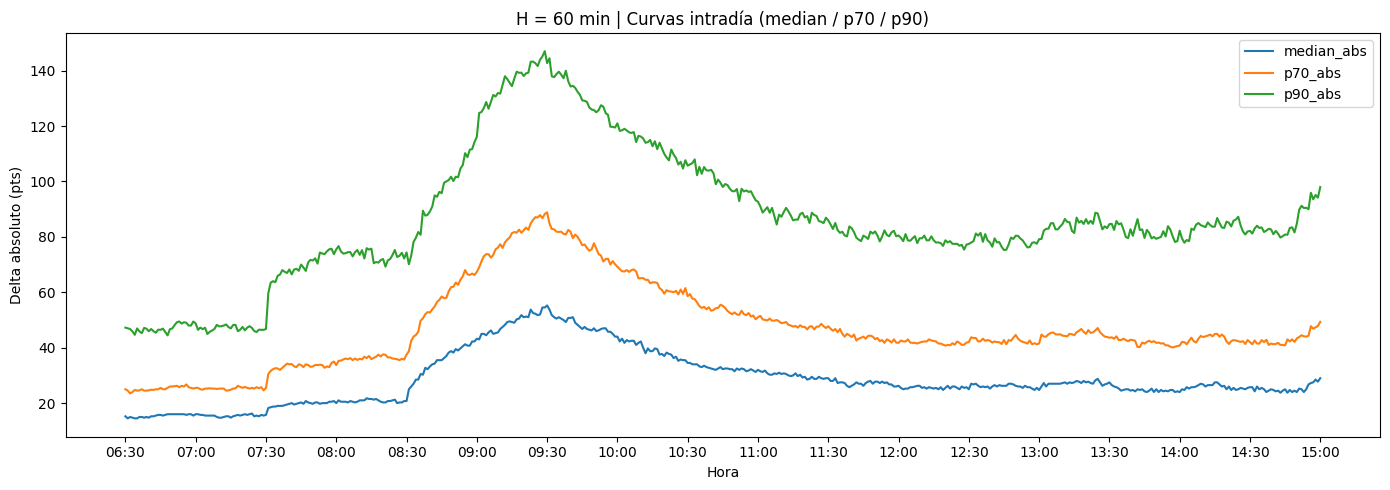


H60 - Ranking horario:

Top 30 según 'median_abs'
Ventana horaria: 09:13  →  09:42
median_abs mínimo: 49.00
median_abs máximo: 55.25
Top 30 según 'p70_abs'
Ventana horaria: 09:14  →  09:43
p70_abs mínimo: 79.50
p70_abs máximo: 88.85
Top 30 según 'p90_abs'
Ventana horaria: 09:11  →  09:41
p90_abs mínimo: 134.40
p90_abs máximo: 147.00


In [126]:
plot_intraday_delta_curves_30min_xticks(
    by_time_60,
    title="H = 60 min | Curvas intradía (median / p70 / p90)"
)

print('\nH60 - Ranking horario:\n')
top_med_60 = top_minutes(by_time_60, col="median_abs", top_n=30)
top_p70_60 = top_minutes(by_time_60, col="p70_abs", top_n=30)
top_p90_60 = top_minutes(by_time_60, col="p90_abs", top_n=30)



- Convergencia horaria muy clara:

  Las tres métricas (mediana, p70 y p90) concentran su máximo rendimiento en una misma ventana estrecha: aproximadamente 09:11–09:43. Esto confirma un régimen intradía estructural, no aleatorio.

- Ventana óptima recomendada:

  El solapamiento efectivo (09:13–09:41) es la ventana ideal de operación para H=60, con alta robustez estadística y baja dependencia del timing exacto.

- Perfil defensivo (delta base):

  La mediana estable entre 49 y 55 pts justifica un delta_base ≈ 50 pts, consistente y repetible.

- Perfil balanceado (objetivo operativo):

  El p70 entre 79.5 y 88.9 pts define un objetivo realista de monetización frecuente, adecuado para un delta_exp intermedio.

- Perfil expansivo (cola):

  El p90 entre 134 y 147 pts confirma la existencia de movimientos explosivos en esa ventana, válidos para estrategias de extensión o trailing.

- Conclusión general:

  Para H=60, el mercado ofrece máxima oportunidad concentrada en una ventana corta, ideal para estrategias con entrada temporalmente acotada y objetivos claros por perfil.

#### **3.3.4 Aplicación a horizonte 90min**

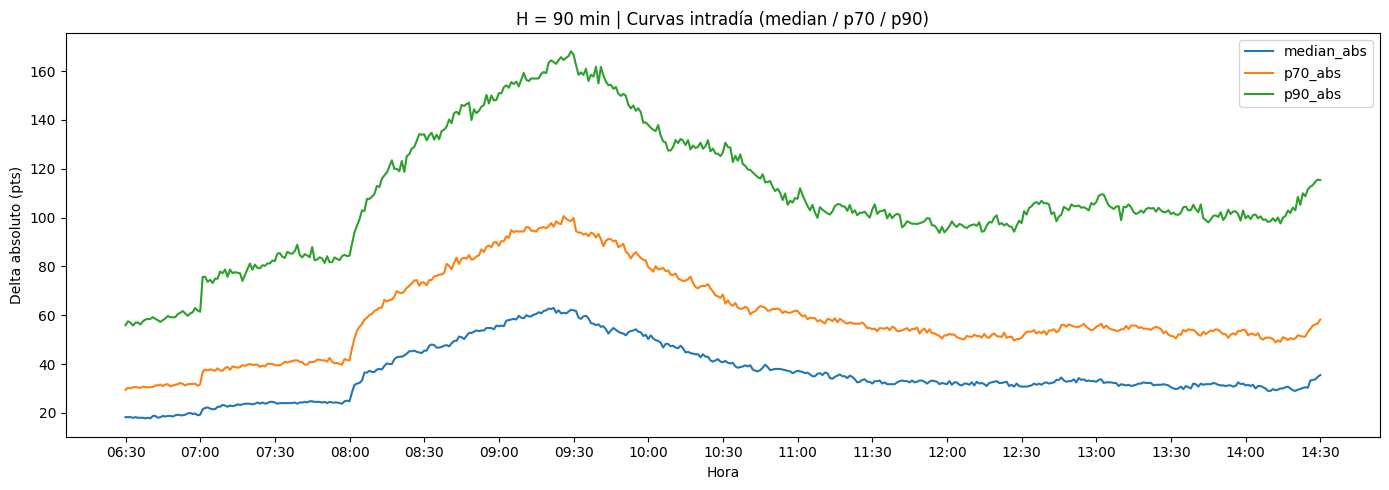


H90 - Ranking horario:

Top 30 según 'median_abs'
Ventana horaria: 09:06  →  09:36
median_abs mínimo: 58.50
median_abs máximo: 63.00
Top 30 según 'p70_abs'
Ventana horaria: 09:05  →  09:37
p70_abs mínimo: 93.85
p70_abs máximo: 100.60
Top 30 según 'p90_abs'
Ventana horaria: 09:09  →  09:42
p90_abs mínimo: 156.45
p90_abs máximo: 168.15


In [128]:
plot_intraday_delta_curves_30min_xticks(
    by_time_90,
    title="H = 90 min | Curvas intradía (median / p70 / p90)"
)
print('\nH90 - Ranking horario:\n')
top_med_90 = top_minutes(by_time_90, col="median_abs", top_n=30)
top_p70_90 = top_minutes(by_time_90, col="p70_abs", top_n=30)
top_p90_90 = top_minutes(by_time_90, col="p90_abs", top_n=30)

- Ventana horaria aún más sólida que en H=60:

  Las tres métricas convergen de forma muy consistente en 09:05–09:42, confirmando un bloque temporal estructural de alta expansión.

- Ventana óptima recomendada:

  El solapamiento efectivo (09:09–09:36) define una ventana ideal amplia y estable, menos sensible al minuto exacto de entrada que H=60.

- Perfil defensivo (delta base):

  La mediana entre 58.5 y 63 pts respalda un delta_base ≈ 60 pts, superior y más estable que en 60 minutos.

- Perfil balanceado (objetivo operativo):

  El p70 entre 94 y 101 pts sugiere un delta_exp moderado con alta probabilidad de ejecución.

- Perfil expansivo (cola):

  El p90 entre 156 y 168 pts confirma movimientos amplios y persistentes, ideales para estrategias de extensión o trailing más agresivas.

- Conclusión general:

  El horizonte 90 min domina en estabilidad y magnitud, ofreciendo mayor tolerancia temporal y mejores colas, a costa de menor frecuencia relativa frente a H=60.

## **4. Comparación estructural entre horizontes (H = 60 vs H = 90)**

---

**1. Ventana horaria**

  **H = 60**  
  - Ventana óptima más estrecha: **~09:13–09:41**.  
  - Requiere mayor precisión de *timing*.

  **H = 90**  
  - Ventana óptima más amplia y estable: **~09:09–09:36**.  
  - Menor sensibilidad al minuto exacto.

  **Ventaja:** H = 90

---

**2. Delta base (perfil defensivo)**

**H = 60**  
- Mediana ≈ **50–55 pts**.

**H = 90**  
- Mediana ≈ **58–63 pts**.

H = 90 ofrece una **mayor base económica** con **robustez comparable**.

**Ventaja:** H = 90

---

**3. Objetivo operativo (p70)**

**H = 60**  
- **80–89 pts**.

**H = 90**  
- **94–101 pts**.

H = 90 mejora el **payoff esperado** sin perder estabilidad.

**Ventaja:** H = 90

---

**4. Cola expansiva (p90)**

**H = 60**  
- **134–147 pts**.

**H = 90**  
- **156–168 pts**.

H = 90 domina claramente en **movimientos grandes y persistentes**.

**Ventaja:** H = 90

---

**5. Frecuencia (probabilidad de exceder niveles)**

**H = 60**  
- Mayor frecuencia absoluta de activación.

**H = 90**  
- Menor frecuencia, pero mejor relación **magnitud / estabilidad**.

**Ventaja operativa:**  
- Trading más activo → **H = 60**  
- Trading más selectivo y robusto → **H = 90**

---

**Conclusión operativa final**

**H = 60**  
- Mayor frecuencia.  
- Ventana más corta.  
- Menor magnitud base.  
- Adecuado para *scalping* direccional o *setups* muy activos.

**H = 90**  
- Ventana amplia.  
- Mayor delta base.  
- Colas más favorables.  
- Menor dependencia temporal.  
- Horizonte dominante para la **definición de targets**.

---

**Decisión tomada**

Adoptamos **H = 90** como **horizonte principal**, y mantenemos **H = 60** como **complementario o secundario**.


## **5. Definición de deltas (H = 60 y H = 90)**

In [129]:
def delta_midpoint(delta_min: float, delta_max: float) -> float:
    """
    Calcula el punto medio entre dos valores de delta.
    """
    return delta_min + (delta_max - delta_min) / 2

In [130]:
delta_base_med_60 = delta_midpoint(
    top_med_60["median_abs"].min(),
    top_med_60["median_abs"].max()
)

delta_target_p70_60 = delta_midpoint(
    top_p70_60["p70_abs"].min(),
    top_p70_60["p70_abs"].max()
)

delta_tail_p90_60 = delta_midpoint(
    top_p90_60["p90_abs"].min(),
    top_p90_60["p90_abs"].max()
)


delta_base_med_90 = delta_midpoint(
    top_med_90["median_abs"].min(),
    top_med_90["median_abs"].max()
)

delta_target_p70_90 = delta_midpoint(
    top_p70_90["p70_abs"].min(),
    top_p70_90["p70_abs"].max()
)

delta_tail_p90_90 = delta_midpoint(
    top_p90_90["p90_abs"].min(),
    top_p90_90["p90_abs"].max()
)

## **6. Ventanas óptimas**

---
**Qué NO es la ventana óptima**

La ventana óptima NO es:
- El rango de datos que el modelo debe “mirar”.
- Ni el input window del modelo.
- Ni el período histórico que se le entrega como features.

El modelo no “ve” el futuro ni opera “dentro” de esa ventana.

---

**Qué SÍ es la ventana óptima**

La ventana óptima es:

  El intervalo horario en el que la predicción tiene mayor valor económico y estadístico.

Es decir:
- Cuándo tiene sentido emitir una predicción.
- Cuándo evaluar su resultado.
- No qué datos usar como input.

**Cómo se relaciona con el modelo (muy importante)**

**1. Datos de entrada (input del modelo)**

El modelo recibe:
- Una ventana histórica previa al instante t (ej. últimos 60 min),
- Siempre anterior al momento de predicción.

Ejemplo:

- Si predice a las 09:15:
  - input = datos 08:15–09:15
  - target = Δ en 09:15 → 10:45 (H=90)

La ventana óptima no cambia esto.

**2. Momento de predicción (cuándo inferir)**

La ventana óptima define en **qué minutos del día** conviene hacer inferencia.

Con H=90:

- Conviene emitir señales entre:
    - 09:09 y 09:36

- Fuera de ese rango:
    - la predicción sigue existiendo, pero su valor esperado es menor.

**3. Evaluación y trading**

Más adelante usted podriamos:

- Evaluar métricas:
  - in-window vs out-window,
- Ejecutar trades:
    - Solo dentro de la ventana óptima,
    - Sin tocar el entrenamiento base.

### **6.2. Ventana óptima por horizonte**

In [152]:
def optimal_window_from_rankings(*tops: pd.DataFrame):
    """
    Recibe varios DataFrames de rankings (top_med, top_p70, top_p90)
    y devuelve la ventana óptima como intersección horaria [HH:MM, HH:MM].
    """

    # Pasamos todo a minute_of_day para comparar correctamente
    mins_start = []
    mins_end = []

    for df in tops:
        minute_of_day = df["hour"] * 60 + df["minute"]
        mins_start.append(minute_of_day.min())
        mins_end.append(minute_of_day.max())

    # Intersección robusta
    start_opt = max(mins_start)
    end_opt = min(mins_end)

    if start_opt > end_opt:
        raise ValueError("No hay intersección horaria entre los rankings.")

    # Formato HH:MM
    start_hhmm = f"{start_opt // 60:02d}:{start_opt % 60:02d}"
    end_hhmm = f"{end_opt // 60:02d}:{end_opt % 60:02d}"

    return {
        "start_minute_of_day": start_opt,
        "end_minute_of_day": end_opt,
        "start_hhmm": start_hhmm,
        "end_hhmm": end_hhmm,
    }

#### **6.2.1. H = 60 minutos**

In [153]:
window_60 = optimal_window_from_rankings(
    top_med_60,
    top_p70_60,
    top_p90_60
)

window_60

{'start_minute_of_day': 554,
 'end_minute_of_day': 581,
 'start_hhmm': '09:14',
 'end_hhmm': '09:41'}

**Ventana óptima H60 (intersección robusta):**

09:14 – 09:41

- Ventana estrecha
- Alta dependencia del timing
- Buena magnitud, menor tolerancia temporal

H = 90 minutos

La convergencia es más amplia y estable, con menor sensibilidad al minuto exacto.

Solapamiento efectivo:

median: 09:06–09:36

p70:  09:05–09:37

p90:  09:09–09:42



#### **6.2.2. H = 90 minutos**

In [154]:
window_90 = optimal_window_from_rankings(
    top_med_90,
    top_p70_90,
    top_p90_90
)

window_90

{'start_minute_of_day': 549,
 'end_minute_of_day': 576,
 'start_hhmm': '09:09',
 'end_hhmm': '09:36'}

**Ventana óptima H90 (intersección robusta):**
09:09 – 09:36

- Ventana más amplia
- Mayor estabilidad
- Mejor relación magnitud / robustez


#### **6.2.3. Conclusión**

- Ventana óptima H60: 09:13–09:41
- Ventana óptima H90: 09:09–09:36

Y, a nivel estratégico:

- H=90 domina como horizonte principal, porque:
  - Ofrece una ventana más tolerante.
  - Mayor delta base y colas.
  - Menor dependencia del minuto exacto de inferencia.

Estas son las ventanas que deben documentarse y pasarse como información estructural a la siguiente notebook, no como filtros duros.

## **7. Determinación  empírica de STOP LOSS**

### **7.1. STOP LOSS y MAE (Maximum Adverse Excursion)**

Una vez definidos el horizonte temporal, la ventana óptima de inferencia y los deltas objetivo (base, operativo y expansivo), es necesario establecer una regla de gestión de riesgo coherente con la dinámica intradía del mercado.

En este punto, el stop loss no se define de forma arbitraria, sino que se deriva empíricamente de los datos, a partir del comportamiento histórico del movimiento adverso que sufre el precio luego de una señal, antes de alcanzar el objetivo o finalizar el horizonte. Este enfoque permite cuantificar el riesgo real asumido por operación y mantener una relación consistente entre riesgo (stop) y retorno esperado (delta objetivo).

En lo que sigue, el stop loss se estimará utilizando estadísticas de excursión adversa por horizonte y horario, garantizando coherencia económica y evitando introducir sesgos o data leakage en el pipeline.

---
**¿Qué es el MAE (Maximum Adverse Excursion)?**

El MAE mide, para una operación hipotética abierta en un instante t, cuál fue el peor movimiento en contra del precio antes de que ocurra alguna de estas dos cosas:

- se alcance el objetivo (take profit), o
- finalice el horizonte temporal de análisis (por ejemplo, 60 o 90 minutos).

En otras palabras, el MAE responde a:

    “¿Cuántos puntos llegó a ir en contra el precio, en el peor momento, antes de resolverse el trade?”

Se expresa en puntos absolutos, y siempre representa riesgo, no retorno.

---
**¿Por qué usar MAE para definir el stop loss?**

Porque el stop loss cumple exactamente la misma función que el MAE describe:
- limitar el movimiento adverso máximo tolerable,
- sin interferir con la lógica de predicción del modelo.

Usar MAE permite:
- derivar el stop directamente de los datos,
- conocer cuánto “respira” el precio antes de acertar o fallar,
- fijar stops que no sean demasiado ajustados (ruido) ni excesivamente amplios (ineficientes).

Al tomar percentiles del MAE (por ejemplo p70 o p80), el stop loss se convierte en una regla robusta, cuantificable y alineada con el comportamiento histórico del mercado, manteniendo una relación consistente entre riesgo y los deltas objetivo definidos previamente.

### **7.2. Consideraciones para el cálculo del MAE**

Para estimar el Maximum Adverse Excursion (MAE) y derivar una regla empírica de stop loss, es necesario explicitar algunos supuestos operativos que definen cómo se simula el comportamiento de una operación en el tiempo. Estos supuestos no afectan al modelo predictivo, sino únicamente al análisis de riesgo.

#### **7.2.1. Regla de salida del trade**

Existen dos enfoques válidos para definir hasta cuándo se mide el MAE de una operación:

**A. MAE hasta el final del horizonte (enfoque conservador y simple)**

- La operación se considera abierta en el instante t.
- Se analiza el comportamiento del precio durante los próximos h minutos.
- El MAE se define como el peor movimiento adverso ocurrido en todo el intervalo [t,t+h].

Este enfoque no requiere definir un take profit, y permite estimar el riesgo máximo potencial asociado al horizonte.

**B. MAE hasta que se alcanza el take profit o vence el horizonte (enfoque más realista)**

- Se define previamente un objetivo económico (por ejemplo, `delta_base` o `delta_op`).

- La operación se considera activa hasta que:
  - se alcanza el take profit, o
  - se cumple el horizonte temporal h, lo que ocurra primero.

- El MAE se mide únicamente hasta ese momento de salida efectiva.

Este segundo enfoque permite estimar el riesgo **realmente asumido** en operaciones exitosas, pero requiere fijar explícitamente qué nivel de objetivo se utiliza como referencia.

#### **7.2.2. Definición del sentido de la operación (LONG / SHORT)**


Para el cálculo empírico del MAE es necesario definir la dirección de cada operación simulada. En esta etapa, **se utiliza una señal direccional “oracle”**, basada en el signo del movimiento futuro real:

- `sign_delta_60` para horizonte de 60 minutos,
- `sign_delta_90` para horizonte de 90 minutos.

Esta señal se emplea exclusivamente para estimar la distribución histórica del riesgo, y no introduce data leakage, ya que no forma parte del entrenamiento del modelo. En etapas posteriores, podrá ser reemplazada por la señal generada por el modelo predictivo.

#### **7.2.3. Información intradía para medir el movimiento adverso**


El cálculo del MAE requiere observar el “camino” del precio dentro del horizonte temporal. Para ello, el `dataset mnq_intraday_with_deltas` ya contiene toda la información necesaria:

- Para una operación LONG, el movimiento adverso se mide como la distancia entre el precio de entrada y el mínimo intradía (`low`) alcanzado durante la vida del trade.

- Para una operación SHORT, el movimiento adverso se mide como la distancia entre el precio de entrada y el máximo intradía (`high`) alcanzado durante la vida del trade.

Dado que el dataset incluye `high` y `low` minuto a minuto, es posible reconstruir de forma precisa la excursión adversa de cada operación simulada.

### **7.3. Cálculo empírico del MAE hasta TP (delta_op)**

#### **7.3.1. Definición operativa**

Sea el instante de entrada $t$ con precio:

$$
P_t = close_t
$$

Sea $h$ el horizonte máximo (en minutos) y $TP$ el objetivo en puntos.

---

**LONG $(+1)$**

$$
TP_{\text{price}} = P_t + TP
$$

$$
\tau = \min\left( \left\{ u \le h \;:\; high_{t+u} \ge TP_{\text{price}} \right\}, \; h \right)
$$

$$
MAE = P_t - \min_{1 \le u \le \tau} \left( low_{t+u} \right)
$$

---

**SHORT $(-1)$**

$$
TP_{\text{price}} = P_t - TP
$$

$$
\tau = \min\left( \left\{ u \le h \;:\; low_{t+u} \le TP_{\text{price}} \right\}, \; h \right)
$$

$$
MAE = \max_{1 \le u \le \tau} \left( high_{t+u} \right) - P_t
$$

---

**Interpretación**

$$
MAE \ge 0
$$

El $MAE$ queda expresado en puntos y representa el riesgo máximo adverso asumido por la operación.

#### **7.3.2. Código**

In [161]:
!pip install numba

In [162]:
import numpy as np
import pandas as pd
from numba import njit

@njit
def _mae_until_tp_numba(close, high, low, sign, h, tp_pts):
    """
    Calcula MAE hasta TP o hasta horizonte h (lo que ocurra primero).
    Implementación rápida (Numba) para un solo día.
    """
    n = close.shape[0]
    mae = np.full(n, np.nan)
    tp_hit = np.zeros(n, dtype=np.bool_)
    tau = np.full(n, np.nan)

    for i in range(n):
        # Si no hay h minutos hacia adelante, no se puede calcular
        if i + h >= n:
            continue

        s = sign[i]
        if not np.isfinite(s) or s == 0.0:
            continue

        entry = close[i]
        u_exit = h  # por defecto: vence el horizonte

        if s > 0:  # LONG
            tp_price = entry + tp_pts

            # Buscar primer u (1..h) donde high[i+u] >= tp_price
            for u in range(1, h + 1):
                if high[i + u] >= tp_price:
                    u_exit = u
                    tp_hit[i] = True
                    break

            # MAE LONG: entry - min(low) en [i+1, i+u_exit]
            min_low = low[i + 1]
            for u in range(2, u_exit + 1):
                v = low[i + u]
                if v < min_low:
                    min_low = v

            mae[i] = entry - min_low
            tau[i] = u_exit

        else:      # SHORT
            tp_price = entry - tp_pts

            # Buscar primer u (1..h) donde low[i+u] <= tp_price
            for u in range(1, h + 1):
                if low[i + u] <= tp_price:
                    u_exit = u
                    tp_hit[i] = True
                    break

            # MAE SHORT: max(high) en [i+1, i+u_exit] - entry
            max_high = high[i + 1]
            for u in range(2, u_exit + 1):
                v = high[i + u]
                if v > max_high:
                    max_high = v

            mae[i] = max_high - entry
            tau[i] = u_exit

    return mae, tp_hit, tau


def compute_mae_until_tp_fast(
    df: pd.DataFrame,
    h: int,
    tp_pts: float,
    date_col: str = "date",
    close_col: str = "close",
    high_col: str = "high",
    low_col: str = "low",
    sign_col: str | None = None,  # por defecto: sign_delta_{h}
) -> pd.DataFrame:
    """
    Wrapper por día (evita cruzar sesiones) + Numba para velocidad.
    Devuelve columnas:
      - mae_tp_{h}
      - tp_hit_{h}
      - tau_{h}
    """
    if sign_col is None:
        sign_col = f"sign_delta_{h}"

    required = {date_col, close_col, high_col, low_col, sign_col}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"Faltan columnas requeridas: {missing}")

    mae_out = np.full(len(df), np.nan, dtype=float)
    hit_out = np.zeros(len(df), dtype=bool)
    tau_out = np.full(len(df), np.nan, dtype=float)

    # Trabajamos por bloques de día. Importante: conservar orden del df.
    # Para asignar rápido, usamos posiciones (iloc) del bloque.
    for _, g in df.groupby(date_col, sort=False):
        pos = g.index.to_numpy()
        # Convertimos a posiciones enteras en el df (para asignar en arrays)
        # Si el índice no es RangeIndex, usamos get_indexer (una vez por día).
        locs = df.index.get_indexer(pos)

        close = g[close_col].to_numpy(dtype=np.float64)
        high = g[high_col].to_numpy(dtype=np.float64)
        low  = g[low_col].to_numpy(dtype=np.float64)
        sign = g[sign_col].to_numpy(dtype=np.float64)

        mae_d, hit_d, tau_d = _mae_until_tp_numba(close, high, low, sign, h, tp_pts)

        mae_out[locs] = mae_d
        hit_out[locs] = hit_d
        tau_out[locs] = tau_d

    return pd.DataFrame(
        {
            f"mae_tp_{h}": mae_out,
            f"tp_hit_{h}": hit_out,
            f"tau_{h}": tau_out,
        },
        index=df.index
    )


Aplicación con nuestros deltas

In [163]:
print(f'delta_target_p70_60: {delta_target_p70_60}')
print(f'delta_target_p70_90: {delta_target_p70_90}')

delta_target_p70_60: 84.175
delta_target_p70_90: 97.225


In [164]:
mae_60 = compute_mae_until_tp_fast(mnq_intraday_with_deltas, h=60, tp_pts=delta_target_p70_60)
mae_90 = compute_mae_until_tp_fast(mnq_intraday_with_deltas, h=90, tp_pts=delta_target_p70_90)

mnq_mae = mnq_intraday_with_deltas.join(mae_60).join(mae_90)
mnq_mae[["mae_tp_60","tp_hit_60","tau_60","mae_tp_90","tp_hit_90","tau_90"]].head()


,mae_tp_60,tp_hit_60,tau_60,mae_tp_90,tp_hit_90,tau_90
datetime,,,,,,
2019-12-23 06:30:00-05:00,3.00,False,60.0,3.00,False,90.0
2019-12-23 06:31:00-05:00,1.75,False,60.0,1.75,False,90.0
2019-12-23 06:32:00-05:00,0.50,False,60.0,0.50,False,90.0
2019-12-23 06:33:00-05:00,0.75,False,60.0,0.75,False,90.0
2019-12-23 06:34:00-05:00,0.75,False,60.0,0.75,False,90.0


#### **NOTA IMPORTANTE (para evitar confusiones)**

Este cálculo usa `sign_delta_{h}` como dirección “oracle” solo para estimar la distribución histórica del riesgo (stop). En etapas posteriores se reemplaza por la señal del modelo.

### **7.4. Percentiles del MAE por horario**



El objetivo es calcular, para cada minute_of_day y cada horizonte:

- p70 y p80 del MAE
- usando mae_tp_60 y mae_tp_90
- solo sobre observaciones válidas (MAE no NaN)

#### **7.4.1. Función genérica para percentiles de MAE**

In [165]:
import pandas as pd
import numpy as np

def mae_percentiles_by_time(
    df: pd.DataFrame,
    mae_col: str,
    percentiles=(0.7, 0.8),
    minute_col: str = "minute_of_day",
) -> pd.DataFrame:
    """
    Calcula percentiles del MAE por minute_of_day.

    Parámetros
    ----------
    df : DataFrame
        Dataset que contiene mae_tp_h y minute_of_day.
    mae_col : str
        Nombre de la columna MAE (ej: 'mae_tp_60').
    percentiles : tuple
        Percentiles a calcular (ej: (0.7, 0.8)).
    """

    base = df[[minute_col, mae_col]].dropna().copy()
    g = base.groupby(minute_col)[mae_col]

    out = pd.DataFrame(index=g.size().index)
    out["n"] = g.size()

    for p in percentiles:
        out[f"p{int(p*100)}"] = g.quantile(p)

    # Reconstrucción HH:MM
    out = out.reset_index()
    out["hour"] = (out[minute_col] // 60).astype(int)
    out["minute"] = (out[minute_col] % 60).astype(int)
    out["time_hm"] = (
        out["hour"].astype(str).str.zfill(2) + ":" +
        out["minute"].astype(str).str.zfill(2)
    )

    return out.sort_values(minute_col).reset_index(drop=True)


#### **7.4.2. Aplicación a H = 60 y H = 90**

In [167]:
# H = 60
mae_pct_60 = mae_percentiles_by_time(
    mnq_mae,
    mae_col="mae_tp_60",
    percentiles=(0.7, 0.8)
)

# H = 90
mae_pct_90 = mae_percentiles_by_time(
    mnq_mae,
    mae_col="mae_tp_90",
    percentiles=(0.7, 0.8)
)



In [168]:
mae_pct_60.head()

,minute_of_day,n,p70,p80,hour,minute,time_hm
0,390,1297,12.50,15.75,6,30,06:30
1,391,1296,12.50,16.50,6,31,06:31
2,392,1296,12.50,16.75,6,32,06:32
3,393,1294,12.75,16.25,6,33,06:33
4,394,1298,12.50,16.00,6,34,06:34


In [169]:
mae_pct_90.head()

,minute_of_day,n,p70,p80,hour,minute,time_hm
0,390,1299,15.15,19.00,6,30,06:30
1,391,1299,15.15,19.75,6,31,06:31
2,392,1299,15.25,19.00,6,32,06:32
3,393,1297,15.25,19.25,6,33,06:33
4,394,1297,15.05,19.50,6,34,06:34


**Como lo usamos para el stop loss**

- Stop conservador: stop_loss_h = p80
- Stop balanceado: stop_loss_h = p70

Luego, igual que hicimos con los deltas, vamos a:

- Mirar solo la ventana óptima (H60: 09:13–09:41, H90: 09:09–09:36)
- Resumir esos percentiles (mediana o media)
- Cerrar un único stop por horizonte.

### **7.5 Ranking horario del MAE y definición del stop loss**

#### **7.5.1. Rankings horarios por MAE (p70 / p80)**

Usamos los percentiles ya calculados (`mae_pct_60`, `mae_pct_90`) y armamos rankings por severidad del riesgo.

In [170]:
def top_minutes_mae(
    mae_pct: pd.DataFrame,
    col: str,
    top_n: int = 30
) -> pd.DataFrame:
    """
    Devuelve el top horarios según un percentil del MAE (p70 o p80).
    """
    cols_show = [
        "hour", "minute", "time_hm",
        "n", col
    ]

    top_df = (
        mae_pct
        .sort_values(col, ascending=False)
        [cols_show]
        .head(top_n)
        .copy()
    )

    return top_df


Aplicación:

In [171]:
# H = 60
top_mae_p70_60 = top_minutes_mae(mae_pct_60, col="p70", top_n=30)
top_mae_p80_60 = top_minutes_mae(mae_pct_60, col="p80", top_n=30)

# H = 90
top_mae_p70_90 = top_minutes_mae(mae_pct_90, col="p70", top_n=30)
top_mae_p80_90 = top_minutes_mae(mae_pct_90, col="p80", top_n=30)

#### **7.5.2. Intersección horaria (ventana de riesgo estable)**

Reutilizamos exactamente el mismo criterio que con los targets: intersección de ventanas.

In [173]:
def optimal_window_from_mae_rankings(*tops: pd.DataFrame):
    """
    Calcula la intersección horaria robusta a partir de rankings de MAE.
    """
    starts = []
    ends = []

    for df in tops:
        mod = df["hour"] * 60 + df["minute"]
        starts.append(mod.min())
        ends.append(mod.max())

    start_opt = max(starts)
    end_opt = min(ends)

    if start_opt > end_opt:
        raise ValueError("No hay intersección horaria entre rankings de MAE.")

    return {
        "start_minute_of_day": start_opt,
        "end_minute_of_day": end_opt,
        "start_hhmm": f"{start_opt // 60:02d}:{start_opt % 60:02d}",
        "end_hhmm": f"{end_opt // 60:02d}:{end_opt % 60:02d}",
    }


Aplicación:

In [175]:
window_mae_60 = optimal_window_from_mae_rankings(
    top_mae_p70_60,
    top_mae_p80_60
)

window_mae_90 = optimal_window_from_mae_rankings(
    top_mae_p70_90,
    top_mae_p80_90
)

In [176]:
window_mae_60

{'start_minute_of_day': 548,
 'end_minute_of_day': 579,
 'start_hhmm': '09:08',
 'end_hhmm': '09:39'}

In [177]:
window_mae_90

{'start_minute_of_day': 538,
 'end_minute_of_day': 578,
 'start_hhmm': '08:58',
 'end_hhmm': '09:38'}

#### **7.5.3. Filtrar MAE solo dentro de la ventana óptima de trading**

Ahora alineamos riesgo con oportunidad, usando las ventanas que ya cerramos:

In [182]:
print(f'H60: {window_60["start_hhmm"]} – {window_60["end_hhmm"]}')
print(f'H90: {window_90["start_hhmm"]} – {window_90["end_hhmm"]}')

H60: 09:14 – 09:41
H90: 09:09 – 09:36


In [183]:
def filter_window(df, start_hhmm, end_hhmm):
    start = int(start_hhmm.split(":")[0]) * 60 + int(start_hhmm.split(":")[1])
    end = int(end_hhmm.split(":")[0]) * 60 + int(end_hhmm.split(":")[1])
    return df[(df["minute_of_day"] >= start) & (df["minute_of_day"] <= end)].copy()

In [187]:
# Ventanas finales ya definidas
optimal_window_60 = (window_60["start_hhmm"], window_60["end_hhmm"])
optimal_window_90 = (window_90["start_hhmm"], window_90["end_hhmm"])

mae_pct_60_win = filter_window(mae_pct_60, *optimal_window_60)
mae_pct_90_win = filter_window(mae_pct_90, *optimal_window_90)

#### **7.5.4. Cierre del stop loss por horizonte**

Tomamos un único valor por horizonte, robusto y defendible.

**Reglas claras**:
- Stop balanceado: mediana del p70
- Stop conservador: mediana del p80

In [188]:
stop_loss_60_p70 = mae_pct_60_win["p70"].median()
stop_loss_60_p80 = mae_pct_60_win["p80"].median()

stop_loss_90_p70 = mae_pct_90_win["p70"].median()
stop_loss_90_p80 = mae_pct_90_win["p80"].median()

stop_loss_60_p70, stop_loss_60_p80, stop_loss_90_p70, stop_loss_90_p80

(37.83749999999999, 49.80000000000001, 43.425, 56.75)

In [191]:
def print_stoploss_summary(
    stop_loss_60_p70, stop_loss_60_p80,
    stop_loss_90_p70, stop_loss_90_p80,
    window_60=optimal_window_60,
    window_90=optimal_window_90,
    decimals=2
):
    print("="*65)
    print("7.5  STOP LOSS (MAE hasta TP = delta_op) | Resumen final")
    print("="*65)

    print(f"\nH = 60 min | Ventana óptima: {window_60[0]} → {window_60[1]}")
    print(f"  • Stop balanceado (p70 MAE): {stop_loss_60_p70:.{decimals}f} pts")
    print(f"  • Stop conservador (p80 MAE): {stop_loss_60_p80:.{decimals}f} pts")

    print(f"\nH = 90 min | Ventana óptima: {window_90[0]} → {window_90[1]}")
    print(f"  • Stop balanceado (p70 MAE): {stop_loss_90_p70:.{decimals}f} pts")
    print(f"  • Stop conservador (p80 MAE): {stop_loss_90_p80:.{decimals}f} pts")

    print("\nNota:")
    print("  - p70 = stop más frecuente (menos holgura)")
    print("  - p80 = stop más robusto (más holgura)")
    print("="*65)

# Uso
print_stoploss_summary(
    stop_loss_60_p70, stop_loss_60_p80,
    stop_loss_90_p70, stop_loss_90_p80
)

7.5  STOP LOSS (MAE hasta TP = delta_op) | Resumen final

H = 60 min | Ventana óptima: 09:14 → 09:41
  • Stop balanceado (p70 MAE): 37.84 pts
  • Stop conservador (p80 MAE): 49.80 pts

H = 90 min | Ventana óptima: 09:09 → 09:36
  • Stop balanceado (p70 MAE): 43.42 pts
  • Stop conservador (p80 MAE): 56.75 pts

Nota:
  - p70 = stop más frecuente (menos holgura)
  - p80 = stop más robusto (más holgura)


In [190]:
import pandas as pd

def stoploss_report_df(
    stop_loss_60_p70, stop_loss_60_p80,
    stop_loss_90_p70, stop_loss_90_p80,
    window_60=("09:13","09:41"),
    window_90=("09:09","09:36"),
    decimals=2
):
    report = pd.DataFrame([
        {"horizon_min": 60, "optimal_window": f"{window_60[0]}–{window_60[1]}", "stop_p70_pts": stop_loss_60_p70, "stop_p80_pts": stop_loss_60_p80},
        {"horizon_min": 90, "optimal_window": f"{window_90[0]}–{window_90[1]}", "stop_p70_pts": stop_loss_90_p70, "stop_p80_pts": stop_loss_90_p80},
    ])

    # Redondeo para presentación
    report["stop_p70_pts"] = report["stop_p70_pts"].round(decimals)
    report["stop_p80_pts"] = report["stop_p80_pts"].round(decimals)

    return report

# Uso
report_sl = stoploss_report_df(
    stop_loss_60_p70, stop_loss_60_p80,
    stop_loss_90_p70, stop_loss_90_p80
)
report_sl

,horizon_min,optimal_window,stop_p70_pts,stop_p80_pts
0,60,09:13–09:41,37.84,49.80
1,90,09:09–09:36,43.42,56.75


## **8. Resumen final**

### **8.1. Implementación**

In [196]:
import pandas as pd
import numpy as np

def build_stage03a_summary_table_with_rr_and_stop(
    # deltas H=60
    delta_base_med_60, delta_target_p70_60, delta_tail_p90_60,
    # deltas H=90
    delta_base_med_90, delta_target_p70_90, delta_tail_p90_90,
    # ventanas óptimas (HH:MM)
    window_60=("09:13","09:41"),
    window_90=("09:09","09:36"),
    # stop loss (MAE hasta TP=delta_op)
    stop_loss_60_p70=None, stop_loss_60_p80=None,
    stop_loss_90_p70=None, stop_loss_90_p80=None,
    # regla de recomendación
    rr_min: float = 2.0,
    decimals: int = 2
) -> pd.DataFrame:
    """
    Tabla resumen con:
      - deltas base/target/tail por horizonte
      - ventana óptima por horizonte
      - stop loss p70/p80 por horizonte
      - R/R en 4 combinaciones
      - stop_recomendado:
          * elige SL_p70 si (delta_target_p70 / SL_p70) >= rr_min
          * si no, elige SL_p80
        y RR_recomendado correspondiente.
    """

    rows = [
        {
            "horizon_min": 60,
            "optimal_window": f"{window_60[0]}–{window_60[1]}",
            "delta_base_med": delta_base_med_60,
            "delta_target_p70": delta_target_p70_60,
            "delta_tail_p90": delta_tail_p90_60,
            "stop_loss_p70": stop_loss_60_p70,
            "stop_loss_p80": stop_loss_60_p80,
        },
        {
            "horizon_min": 90,
            "optimal_window": f"{window_90[0]}–{window_90[1]}",
            "delta_base_med": delta_base_med_90,
            "delta_target_p70": delta_target_p70_90,
            "delta_tail_p90": delta_tail_p90_90,
            "stop_loss_p70": stop_loss_90_p70,
            "stop_loss_p80": stop_loss_90_p80,
        },
    ]

    df = pd.DataFrame(rows)

    # Asegurar floats
    num_cols = ["delta_base_med", "delta_target_p70", "delta_tail_p90", "stop_loss_p70", "stop_loss_p80"]
    for c in num_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # R/R (Reward / Risk)
    df["RR_target_p70_vs_SL_p70"] = df["delta_target_p70"] / df["stop_loss_p70"]
    df["RR_target_p70_vs_SL_p80"] = df["delta_target_p70"] / df["stop_loss_p80"]
    df["RR_tail_p90_vs_SL_p70"]   = df["delta_tail_p90"]   / df["stop_loss_p70"]
    df["RR_tail_p90_vs_SL_p80"]   = df["delta_tail_p90"]   / df["stop_loss_p80"]

    # Reglas de recomendación:
    # Preferimos el stop más ajustado (p70) SI cumple el umbral rr_min.
    # Si no cumple, usamos p80 (más holgado). Si alguno está NaN, elegimos el disponible.
    def recommend_stop(row):
        rr_p70 = row["RR_target_p70_vs_SL_p70"]
        sl_p70 = row["stop_loss_p70"]
        sl_p80 = row["stop_loss_p80"]

        # Casos con NaN
        if pd.isna(sl_p70) and pd.isna(sl_p80):
            return pd.Series({"stop_recomendado": np.nan, "stop_recomendado_tipo": "NA", "RR_recomendado": np.nan})

        if pd.isna(sl_p70):
            rr = row["RR_target_p70_vs_SL_p80"]
            return pd.Series({"stop_recomendado": sl_p80, "stop_recomendado_tipo": "p80", "RR_recomendado": rr})

        if pd.isna(sl_p80):
            rr = row["RR_target_p70_vs_SL_p70"]
            return pd.Series({"stop_recomendado": sl_p70, "stop_recomendado_tipo": "p70", "RR_recomendado": rr})

        # Ambos disponibles
        if pd.notna(rr_p70) and rr_p70 >= rr_min:
            return pd.Series({"stop_recomendado": sl_p70, "stop_recomendado_tipo": "p70", "RR_recomendado": rr_p70})
        else:
            rr = row["RR_target_p70_vs_SL_p80"]
            return pd.Series({"stop_recomendado": sl_p80, "stop_recomendado_tipo": "p80", "RR_recomendado": rr})

    rec = df.apply(recommend_stop, axis=1)
    df = pd.concat([df, rec], axis=1)

    # Redondeo
    for c in num_cols + [
        "RR_target_p70_vs_SL_p70",
        "RR_target_p70_vs_SL_p80",
        "RR_tail_p90_vs_SL_p70",
        "RR_tail_p90_vs_SL_p80",
        "stop_recomendado",
        "RR_recomendado",
    ]:
        df[c] = df[c].round(decimals)

    # Orden de columnas final
    df = df[
        ["horizon_min", "optimal_window",
         "delta_base_med", "delta_target_p70", "delta_tail_p90",
         "stop_loss_p70", "stop_loss_p80",
         "RR_target_p70_vs_SL_p70", "RR_target_p70_vs_SL_p80",
         "RR_tail_p90_vs_SL_p70",   "RR_tail_p90_vs_SL_p80",
         "stop_recomendado_tipo", "stop_recomendado", "RR_recomendado"]
    ]

    return df



In [198]:
summary_tbl = build_stage03a_summary_table_with_rr_and_stop(
    delta_base_med_60, delta_target_p70_60, delta_tail_p90_60,
    delta_base_med_90, delta_target_p70_90, delta_tail_p90_90,
    window_60=optimal_window_60,
    window_90=optimal_window_90,
    stop_loss_60_p70=stop_loss_60_p70,
    stop_loss_60_p80=stop_loss_60_p80,
    stop_loss_90_p70=stop_loss_90_p70,
    stop_loss_90_p80=stop_loss_90_p80,
    decimals=2
)

### **8.2. Conclusiones**

In [199]:
summary_tbl

,horizon_min,optimal_window,delta_base_med,delta_target_p70,delta_tail_p90,stop_loss_p70,stop_loss_p80,RR_target_p70_vs_SL_p70,RR_target_p70_vs_SL_p80,RR_tail_p90_vs_SL_p70,RR_tail_p90_vs_SL_p80,stop_recomendado_tipo,stop_recomendado,RR_recomendado
0,60,09:14–09:41,52.12,84.18,140.7,37.84,49.80,2.22,1.69,3.72,2.83,p70,37.84,2.22
1,90,09:09–09:36,60.75,97.22,162.3,43.42,56.75,2.24,1.71,3.74,2.86,p70,43.42,2.24


**1. Ventanas óptimas y estabilidad temporal**

- **H = 60 min**: ventana óptima **09:14–09:41**, más estrecha y altamente dependiente del *timing*.
- **H = 90 min**: ventana óptima **09:09–09:36**, más amplia y estructuralmente más estable.

El horizonte de **90 minutos** mantiene una ventaja clara en tolerancia temporal sin pérdida de magnitud.

---

**2. Deltas objetivo vs riesgo asumido**

En ambos horizontes, los **delta\_target\_p70** (≈ **84 pts** en *H60* y ≈ **97 pts** en *H90*) son:

- Claramente superiores al **delta\_base\_med**.  
- Consistentes con colas relevantes (**delta\_tail\_p90 > 140 pts**).

Esto confirma que los objetivos definidos capturan movimientos **económicamente significativos**.

---

**3. Stop loss empírico (MAE hasta TP)**

Los *stop loss* derivados del **MAE** muestran:

- **H = 60 min**  
  - p70 ≈ **38 pts**  
  - p80 ≈ **50 pts**

- **H = 90 min**  
  - p70 ≈ **43 pts**  
  - p80 ≈ **57 pts**

El incremento del *stop* con el horizonte es **proporcional y razonable**, reflejando mayor exposición temporal.

---

**4. Evaluación Risk / Reward (R/R)**

Usando *stop p70*, ambos horizontes presentan:

- **R/R ≈ 2.2** para el objetivo *p70*.  
- **R/R > 3.7** para escenarios de cola (*p90*).

Con *stop p80*, el **R/R cae por debajo de 2.0** para el *target p70*, volviéndose menos atractivo.

---

**5. Stop recomendado**

En ambos horizontes, el **stop p70** es el recomendado:

- Cumple el umbral mínimo **R/R ≥ 2.0**.  
- Mantiene un equilibrio adecuado entre **protección y eficiencia**.

El *stop p80* queda como alternativa **conservadora**, a costa de reducir el R/R.

---

**6. Comparación final: H60 vs H90**

El horizonte **H = 90 min** domina estructuralmente:

- Mayor delta objetivo.  
- Ventana operativa más estable.  
- R/R ligeramente superior (**2.24 vs 2.22**).

El horizonte **H = 60 min** sigue siendo viable, pero exige **mayor precisión temporal**.

### **8.3. Conclusión general**



El análisis empírico confirma que la estrategia es económicamente viable, con una relación riesgo/retorno sólida y consistente entre horizontes.
El horizonte de 90 minutos, combinado con un stop loss basado en MAE p70, emerge como la opción preferente para la siguiente etapa del pipeline.

In [204]:
import json
from pathlib import Path

artifact = {
    "stage": "stage_03a_target_investigation",
    "description": "Resumen final de targets, ventanas óptimas y stop loss empírico (MAE hasta TP=delta_op).",
    "horizons": {
        "60": {
            "optimal_window": {
                "start": "09:14",
                "end": "09:41"
            },
            "deltas": {
                "base_med": 52.12,
                "target_p70": 84.18,
                "tail_p90": 140.70
            },
            "stop_loss": {
                "p70": 37.84,
                "p80": 49.80,
                "recommended": {
                    "type": "p70",
                    "value": 37.84
                }
            },
            "risk_reward": {
                "target_p70_vs_sl_p70": 2.22,
                "target_p70_vs_sl_p80": 1.69,
                "tail_p90_vs_sl_p70": 3.72,
                "tail_p90_vs_sl_p80": 2.83,
                "recommended_rr": 2.22
            }
        },
        "90": {
            "optimal_window": {
                "start": "09:09",
                "end": "09:36"
            },
            "deltas": {
                "base_med": 60.75,
                "target_p70": 97.22,
                "tail_p90": 162.30
            },
            "stop_loss": {
                "p70": 43.42,
                "p80": 56.75,
                "recommended": {
                    "type": "p70",
                    "value": 43.42
                }
            },
            "risk_reward": {
                "target_p70_vs_sl_p70": 2.24,
                "target_p70_vs_sl_p80": 1.71,
                "tail_p90_vs_sl_p70": 3.74,
                "tail_p90_vs_sl_p80": 2.86,
                "recommended_rr": 2.24
            }
        }
    }
}

artifact_path = Path("/content/drive/MyDrive/neural_profit/artifacts/stage_03a_targets_and_stops.json")
artifact_path.parent.mkdir(parents=True, exist_ok=True)

with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(artifact, f, indent=2, ensure_ascii=False)

artifact_path


PosixPath('/content/drive/MyDrive/neural_profit/artifacts/stage_03a_targets_and_stops.json')